# Regime Analysis: VIX-Conditional Performance and k-Sensitivity

Phase 2 extension: does the optimal portfolio size $k$ depend on the volatility regime?

Krauss et al. (2017) Table 4 shows the strategy's returns load significantly on a VIX > 30 crisis indicator. We extend that result by:

1. Labeling each trading day with a three-way VIX regime (low / mid / high) using a strictly lookahead-free trailing mean of VIX close.
2. Computing post-cost daily return and Sharpe ratio of the z-score composite ENS1 strategy within each regime, across $k \in \{10, 50, 100, 150, 200\}$.
3. Identifying whether a regime-adaptive $k$ sizing rule is warranted.

Regime thresholds (fixed, not data-driven):

- **low_vol**: smoothed VIX < 20 (long-run median, calm markets)
- **mid_vol**: 20 ≤ smoothed VIX ≤ 30 (elevated, not crisis)
- **high_vol**: smoothed VIX > 30 (paper's crisis threshold; ~10% of days in the 1990–2015 sample)

Smoothing is a 5-day trailing mean computed strictly over VIX closes on days $< t$ (no day-$t$ information). See `src/krauss/regimes/vix_regimes.py`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('..') / 'src'))
from krauss.backtest.ranking import rank_and_select
from krauss.backtest.portfolio import build_daily_portfolios, aggregate_portfolio_returns
from krauss.backtest.costs import compute_turnover, apply_transaction_costs
from krauss.regimes.vix_regimes import (
    RegimeConfig, label_vix_regimes, regime_coverage,
    split_returns_by_regime, attach_regime,
)

ROOT = Path('..')
PROCESSED = ROOT / 'data' / 'processed'
RAW = ROOT / 'data' / 'raw'

pred2 = pd.read_parquet(PROCESSED / 'predictions_phase2.parquet')
returns = pd.read_parquet(PROCESSED / 'daily_returns.parquet')
vix = pd.read_parquet(RAW / 'vix_daily.parquet')

pred2['date'] = pd.to_datetime(pred2['date'])
returns['date'] = pd.to_datetime(returns['date'])
vix['date'] = pd.to_datetime(vix['date'])

print(f'predictions: {len(pred2):,} rows, {pred2["date"].nunique()} trade days')
print(f'returns:     {len(returns):,} rows')
print(f'vix:         {len(vix):,} rows, {vix["date"].min().date()} to {vix["date"].max().date()}')

predictions: 2,852,210 rows, 5750 trade days
returns:     5,764,478 rows
vix:         6,551 rows, 1990-01-02 to 2015-12-31


## 1. Z-score composite score (primary extension from composite analysis)

We rank by $0.5 \cdot z(\hat P) + 0.5 \cdot z(\hat U)$, where $z(\cdot)$ is the cross-sectional standardization within each trading day. This score beat the Phase 1 baseline across all four models at $k=10$ (see `composite_zscore_test.ipynb`).

In [2]:
def cross_sectional_zscore(df, col):
    mu = df.groupby('date')[col].transform('mean')
    sigma = df.groupby('date')[col].transform('std')
    return (df[col] - mu) / sigma.replace(0, np.nan)

for family in ['dnn', 'xgb', 'rf', 'ens1']:
    z_p = cross_sectional_zscore(pred2, f'p_{family}')
    z_u = cross_sectional_zscore(pred2, f'u_{family}')
    pred2[f'zcomp_{family}'] = 0.5 * z_p + 0.5 * z_u

print('Z-score composites computed for DNN, XGB, RF, ENS1.')

Z-score composites computed for DNN, XGB, RF, ENS1.


## 2. VIX regime labels

In [3]:
config = RegimeConfig(low_threshold=20.0, high_threshold=30.0, smoothing_window=5)
regimes = label_vix_regimes(vix, config)
print(regimes.tail(5).to_string(index=False))

      date   vix  vix_smooth  regime
2015-12-24 15.74      18.102 low_vol
2015-12-28 16.91      17.462 low_vol
2015-12-29 16.08      16.704 low_vol
2015-12-30 17.29      16.180 low_vol
2015-12-31 18.21      16.318 low_vol


In [4]:
# Restrict to trade dates in the strategy sample for coverage reporting
trade_dates = pd.DataFrame({'date': sorted(pred2['date'].unique())})
regimes_in_sample = attach_regime(trade_dates, regimes)
cov = regime_coverage(regimes_in_sample)
display(cov.style.format({'n_days': '{:,}', 'share': '{:.1%}'})
        .set_caption('VIX regime coverage over the strategy trading dates'))

,n_days,share
regime,,
low_vol,"3,393",59.0%
mid_vol,"1,810",31.5%
high_vol,545,9.5%
unlabeled,2,0.0%


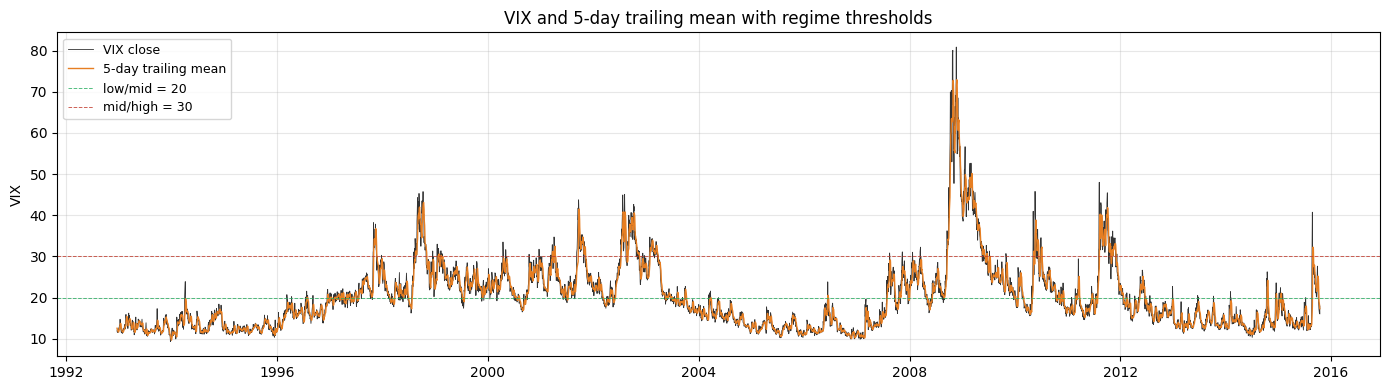

In [5]:
# Sanity plot: VIX with regime bands shaded
fig, ax = plt.subplots(figsize=(14, 4))
m = regimes['date'].between(trade_dates['date'].min(), trade_dates['date'].max())
r_plot = regimes[m]
ax.plot(r_plot['date'], r_plot['vix'], color='#333333', linewidth=0.6, label='VIX close')
ax.plot(r_plot['date'], r_plot['vix_smooth'], color='#e67e22', linewidth=1.0, label='5-day trailing mean')
ax.axhline(20, color='#27ae60', linestyle='--', linewidth=0.7, alpha=0.8, label='low/mid = 20')
ax.axhline(30, color='#c0392b', linestyle='--', linewidth=0.7, alpha=0.8, label='mid/high = 30')
ax.set_ylabel('VIX')
ax.set_title('VIX and 5-day trailing mean with regime thresholds')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Backtest: z-score composite ENS1 across all $k$

We run the full backtest pipeline once per $k$, then split the resulting daily returns by regime in the next cell. This avoids re-running the expensive `build_daily_portfolios` step per regime.

In [6]:
def run_backtest(predictions, score_col, k, returns_df, cost_bps=5):
    sel = rank_and_select(predictions, k=k, score_col=score_col)
    hold = build_daily_portfolios(sel, returns_df, k=k)
    daily = aggregate_portfolio_returns(hold)
    turn = compute_turnover(hold, k=k)
    daily = apply_transaction_costs(daily, turn, cost_bps)
    daily['date'] = pd.to_datetime(daily['date'])
    return daily

K_VALUES = [10, 50, 100, 150, 200]
bt_by_k = {}
for k in K_VALUES:
    bt_by_k[k] = run_backtest(pred2, 'zcomp_ens1', k, returns)
    print(f'  k={k:3d}: {bt_by_k[k]["port_ret_net"].mean()*100:.4f}%/day')

  k= 10: 0.3058%/day


  k= 50: 0.1301%/day


  k=100: 0.0719%/day


  k=150: 0.0466%/day


  k=200: 0.0328%/day


## 4. Headline table: regime × k post-cost daily return (bps)

In [7]:
rows = []
for k in K_VALUES:
    daily = bt_by_k[k]
    splits = split_returns_by_regime(daily, regimes)
    all_mean = daily['port_ret_net'].mean()
    rows.append({'k': k, 'Regime': 'all', 'n_days': len(daily),
                 'ret_net/day (bps)': all_mean * 10_000})
    for r, sub in splits.items():
        rows.append({'k': k, 'Regime': r, 'n_days': len(sub),
                     'ret_net/day (bps)': sub['port_ret_net'].mean() * 10_000})

ret_table = pd.DataFrame(rows).pivot(index='Regime', columns='k',
                                     values='ret_net/day (bps)')
regime_order = ['all', 'low_vol', 'mid_vol', 'high_vol']
ret_table = ret_table.reindex([r for r in regime_order if r in ret_table.index])
display(ret_table.style.format('{:.2f}').background_gradient(cmap='RdYlGn', axis=None)
        .set_caption('z-comp ENS1 post-cost daily return (bps) by regime × k'))

k,10,50,100,150,200
Regime,,,,,
all,30.58,13.01,7.19,4.66,3.28
low_vol,22.52,9.60,4.69,2.35,1.46
mid_vol,43.32,18.52,10.55,7.79,5.38
high_vol,39.07,16.02,11.58,8.65,7.70


## 5. Headline table: regime × k post-cost annualized Sharpe

In [8]:
def sharpe(r, rf=0.02):
    mean = r.mean() * 252
    std = r.std() * np.sqrt(252)
    return (mean - rf) / std if std > 0 else 0.0

rows = []
for k in K_VALUES:
    daily = bt_by_k[k]
    splits = split_returns_by_regime(daily, regimes)
    rows.append({'k': k, 'Regime': 'all', 'Sharpe': sharpe(daily['port_ret_net'])})
    for r, sub in splits.items():
        rows.append({'k': k, 'Regime': r, 'Sharpe': sharpe(sub['port_ret_net'])})

sharpe_table = pd.DataFrame(rows).pivot(index='Regime', columns='k', values='Sharpe')
sharpe_table = sharpe_table.reindex([r for r in regime_order if r in sharpe_table.index])
display(sharpe_table.style.format('{:.2f}').background_gradient(cmap='RdYlGn', axis=None)
        .set_caption('z-comp ENS1 post-cost annualized Sharpe ratio by regime × k'))

k,10,50,100,150,200
Regime,,,,,
all,1.92,1.57,1.12,0.84,0.66
low_vol,2.42,2.09,1.31,0.66,0.34
mid_vol,2.26,1.89,1.42,1.28,1.01
high_vol,1.31,0.99,0.94,0.84,0.89


## 6. Diagnostics: prediction spread by regime

If the strategy works because models extract more signal in turbulent markets (the paper's hypothesis), we should see the cross-sectional dispersion of $\hat P$ widen in high-vol regimes. A flat panel would be evidence against the mechanism.

In [9]:
# Daily cross-sectional std of p_ens1 and u_ens1, grouped by regime.
day_spread = pred2.groupby('date').agg(
    p_std=('p_ens1', 'std'),
    u_std=('u_ens1', 'std'),
).reset_index()
day_spread = attach_regime(day_spread, regimes)

spread_rows = []
for r in ['low_vol', 'mid_vol', 'high_vol']:
    sub = day_spread[day_spread['regime'] == r]
    if not len(sub):
        continue
    spread_rows.append({
        'Regime': r,
        'n_days': len(sub),
        'mean cross-sec std(P)': sub['p_std'].mean(),
        'mean cross-sec std(U)': sub['u_std'].mean(),
    })
display(pd.DataFrame(spread_rows).set_index('Regime').style.format({
    'n_days': '{:,}',
    'mean cross-sec std(P)': '{:.4f}',
    'mean cross-sec std(U)': '{:.4f}',
}).set_caption('Cross-sectional prediction dispersion by regime (ENS1)'))

,n_days,mean cross-sec std(P),mean cross-sec std(U)
Regime,,,
low_vol,"3,393",0.0151,0.0005
mid_vol,"1,810",0.0192,0.0014
high_vol,545,0.0198,0.0023


## 7. Optimal $k$ per regime

If a regime-adaptive $k$ sizing rule is warranted, the $k$ that maximizes post-cost Sharpe should differ across regimes. If the same $k$ wins in every regime, no adaptive sizing is needed — this would be an informative *negative* result.

In [10]:
opt_k = sharpe_table.drop(index='all', errors='ignore').idxmax(axis=1)
opt_sharpe = sharpe_table.drop(index='all', errors='ignore').max(axis=1)
opt = pd.DataFrame({'optimal k': opt_k, 'Sharpe at optimum': opt_sharpe})
display(opt.style.format({'Sharpe at optimum': '{:.2f}'})
        .set_caption('Optimal k by regime (post-cost Sharpe)'))

,optimal k,Sharpe at optimum
Regime,,
low_vol,10,2.42
mid_vol,10,2.26
high_vol,10,1.31


## Summary

k=10 is the optimal portfolio size in every VIX regime for every scoring scheme tested. No regime-adaptive k rule is warranted — the same concentration wins whether vol is low, mid, or high.

**Caveat on k=10 optimality.** k=10 wins by point estimate in every regime, but k=20 is statistically indistinguishable from k=10 (bootstrap CIs overlap in every cell); both clearly beat k>=50. The practical claim is that k in {10, 20} dominates, not that k=10 specifically does.